In [ ]:
from pathlib import Path

import numpy as np
import numpy.typing as npt
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from safetensors import safe_open
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm, trange

from lib.dataset import MatlabDataset, frame_accel_3d, frame_damage, subsample
from lib.densenet import SDIDenseNet
from lib.midn import Midn

In [ ]:
def add_noise(signal: npt.NDArray[np.float_], snr: float) -> npt.NDArray[np.float_]:
    linear_snr = 10.0 ** (snr / 10.0)
    noise_var = signal.var(1)[:, None, :] / linear_snr
    noise_var[np.abs(noise_var) < 1e-12] = linear_snr  # For null signals, use linear_snr directly
    e = np.random.randn(*signal.shape) * (noise_var * 2.0)**0.5 / 2
    return signal + e

In [ ]:
class SafetensorsDataset(Dataset):
    def __init__(self, root: Path | str, getters) -> None:
        super().__init__()
        self.root = Path(root)
        self.files = list(self.root.glob("*.safetensors"))
        self.getters = getters

    def __len__(self) -> int: return len(self.files)

    def __getitem__(self, index: int):
        file = self.files[index]
        data = safe_open(file, framework="numpy")
        return [getter(data) for getter in self.getters]

In [ ]:
# sparse_indices = [3, 6, 8, 10, 16, 47, 50, 53, 56]


def input_preprocess(data, n_sensors=65, sensor_dim=1, snr=-1.0) -> npt.NDArray[np.float32]:
    accel = data.get_tensor("acc").reshape(1000, 65, 3).transpose(2, 0, 1)
    accel = accel[:sensor_dim, :500]
    # accel = accel[..., sparse_indices]
    if snr > 0.0:
        accel = add_noise(accel, snr)
    return accel.astype(np.float32)  # type: ignore


def val_input_preprocess(data, sensor_dim=1, snr=-1.0):
    accel = data.get_tensor("acc").reshape(1000, 65, 3).transpose(2, 0, 1)
    accel = accel[:sensor_dim, :500]
    # accel = accel[..., sparse_indices]
    if snr > 0.0:
        accel = add_noise(accel, snr)
    return accel.astype(np.float32)


def target_preprocess(data) -> npt.NDArray[np.float32]:
    return data.get_tensor("target").astype(np.float32) / 0.15 - 1


def get_dataloaders(name, snr=0.0):
    train_ds = SafetensorsDataset(f"data/safetensors/unc=0/{name}/", [lambda x: input_preprocess(x, snr=snr), target_preprocess])
    val_ds = SafetensorsDataset(f"data/safetensors/unc=0/{name}/", [lambda x: val_input_preprocess(x, snr=snr), target_preprocess])

    train, valtest = train_test_split(np.arange(len(train_ds)), test_size=0.3, random_state=42)
    val, test = train_test_split(valtest, test_size=0.5, random_state=42)

    train_dl = DataLoader(Subset(train_ds, train), batch_size=128, shuffle=True, num_workers=12)
    val_dl = DataLoader(Subset(val_ds, val), batch_size=32, shuffle=False, num_workers=12)
    test_dl = DataLoader(Subset(val_ds, test), batch_size=32, shuffle=False, num_workers=12)
    return train_dl, val_dl, test_dl
# len(train_dl), len(val_dl)

In [ ]:
from lib.midn import importance_dropout


class Midn(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        importance_dropout: float = 0.0,
        temperature: float = 1.0,
        val_temperature: float | None = None,
        pred_activation: "Callable[[], nn.Module]" = nn.Tanh,
    ) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.layer = nn.Conv1d(in_channels, 2 * out_channels, 1)
        self.pred_activation = pred_activation()
        self.temperature = temperature
        self.val_temperature = val_temperature or temperature
        self.importance_dropout = importance_dropout

    def forward(
        self, x: torch.Tensor, reduce: bool = True
    ) -> "Tensor | tuple[Tensor, Tensor]":
        x = self.layer(x)
        prediction = x[:, : self.out_channels, :]
        importance = (
            x[:, self.out_channels :, :] * (self.temperature if self.training else self.val_temperature)
        )
        if self.training:
            importance = importance_dropout(importance, self.importance_dropout)

        importance = importance.softmax(-1)
        dmg_importance, loc_importance = importance[:, :1], importance[:, 1:]
        dmg_prediction, loc_prediction = self.pred_activation(prediction[:, :1]), prediction[:, 1:]

        if reduce:
            return (dmg_prediction * dmg_importance).sum(2), (loc_prediction * loc_importance).sum(2)
        else:
            return dmg_prediction, dmg_importance, loc_prediction, loc_importance

In [ ]:
def get_model():
    dropout = 0.0
    head_dropout = 0.5   # 0.166946
    feature_extractor = SDIDenseNet(1, structure=(6, 6, 6), bn_params={})
    neck = nn.Sequential(
        nn.Flatten(1, 2),
        nn.Conv1d(6000, 768, 1),
        nn.ReLU(True),
        nn.Dropout(dropout),
        nn.Conv1d(768, 768, 1),
        nn.ReLU(True),
    )
    head = Midn(768, 71, head_dropout, temperature=1e-2, val_temperature=1e-2)
    model = nn.Sequential(feature_extractor, neck, head)
    return model

In [ ]:
# def add_noise(signal, snr = None):
#     if snr is None:
#         # snr = torch.from_numpy(np.random.choice([0.0, 10.0, 20.0, 30.0, 30.0], size=(signal.shape[-1],))).to(signal)
#         snr = 30.0
#     linear_snr = 10.0 ** (snr / 10.0)
#     noise_var = signal.var(-2)[..., None, :] / linear_snr
#     msk = torch.abs(noise_var) < 1e-12
#     noise_var[msk] = (linear_snr * (msk))[msk]  # For null signals, use linear_snr directly
#     e = torch.randn(*signal.shape, device=signal.device, dtype=signal.dtype) * (noise_var * 2.0)**0.5 / 2
#     return signal + e

In [ ]:
from random import random


@torch.no_grad()
def randomise_bag_size(x: torch.Tensor, drop_rate: float = 10/65) -> tuple[torch.Tensor, torch.Tensor]:
    while not (mask := torch.rand(x.size(-1)) < drop_rate).any():
        pass
    return x[..., mask]

# @torch.no_grad()
# def randomise_bag_size(x, drop_rate: float = 10/65):
#     drop_rate = 1-(drop_rate / 2)
#     failed = True
#     while failed:
#         mask = torch.rand(x.shape[-1]) > (drop_rate * random() ** 0.33)
#         failed = not mask.any()
#     return x[..., mask]

# @torch.no_grad()
# def randomise_bag_size(x: torch.Tensor) -> torch.Tensor:
#     # mask= torch.rand(x.size(-1)) < (2 ** (torch.rand(x.size(-1)) * 3 + 2.5)).div(65)
#     failed = True
#     while failed:
#         mask = torch.rand(x.size(-1)) < (10/65)
#         failed = not mask.any()
#     return x[..., mask]

In [ ]:
def train_one_epoch(model, opt, sched, train_dl, accel, ema = None) -> float:
    model.train()
    accum = 0.
    for x, y in train_dl:
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]
        opt.zero_grad()
        with accel.autocast():
            # x = x[..., 1:-1]  # remove the stationary sensors
            x = randomise_bag_size(x)
            # x = add_noise(x)
            y_hat_dmg, y_hat_loc = model(x)
            dmg_loss = F.mse_loss(y_hat_dmg, y_dmg)
            loc_loss = F.cross_entropy(y_hat_loc, y_loc)
            loss = dmg_loss + loc_loss
            if ema is not None:
                ema.update_parameters(model)
        accel.backward(loss)
        opt.step()
        sched.step()
        accum += loss.item()
    accum /= len(train_dl)
    return accum

In [ ]:
from functools import lru_cache

@lru_cache
def gen_combos(
    num_combos: int,
    length: int,
    num_sensors: int,
) -> torch.Tensor:
    rng = torch.Generator().manual_seed(42)
    out = torch.empty((num_combos, num_sensors), dtype=torch.long)
    for i in range(num_combos):
        torch.randperm(num_sensors, out=out[i], generator=rng)
        while (out[i:i+1, :length] == out[:i, :length]).all(1).any():
            # ensure no duplicates
            torch.randperm(num_sensors, out=out[i], generator=rng)
    return out[:, :length].T


@torch.inference_mode()
def val_one_epoch(model, val_dl, clen=10) -> float:
    model.eval()
    state = deepcopy(model.state_dict())
    # combos = torch.combinations(torch.arange(65), r=clen)
    combos = gen_combos(51, clen, num_sensors=9)
    total_losses = torch.zeros((combos.size(0),))
    total_mse = torch.zeros((combos.size(0),))
    loc_corr = torch.zeros((combos.size(0),))
    for x, y in val_dl:
        # x = x[..., 1:-1]  # remove the stationary sensors
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]

        y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
        y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
        i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
        i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
        i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
        dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
        loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
        l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
        l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
        l = l_dmg + l_loc
        total_losses += l

        distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
        total_mse += F.mse_loss(distributed_pred, y[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()

        loc_corr += (loc_preds.argmax(1) == y_loc[:, None]).sum(0).cpu()

    model.load_state_dict(state)
    return torch.median(total_losses).item() / len(val_dl.dataset), torch.median(total_mse).item() / len(val_dl.dataset), torch.median(loc_corr).item() / len(val_dl.dataset)

In [ ]:
from scipy.io import loadmat


mat = loadmat("./data/Testing_SingleEAcc9Sensor0.5sec.mat")
test_data = torch.from_numpy(mat["Testing_Data"]).float()
test_target = torch.from_numpy(mat["Testing_label"]).float()
def do_real_test(model):
    with torch.inference_mode():
        model.eval()
        dmg_pred, loc_pred = model(test_data[None, None, ...].cuda())
    dmg_pred = dmg_pred.squeeze().add(1).mul_(0.15).item()
    loc_nll = -(loc_pred.squeeze().log_softmax(-1)[11].item())
    max_nll = -(loc_pred.squeeze().log_softmax(-1).max().item())
    smooth = dmg_pred * loc_pred.squeeze().softmax(-1)
    hard = torch.zeros_like(test_target.squeeze())
    hard[loc_pred.argmax()] = dmg_pred
    return {
        "rw_mse": (dmg_pred - 0.125) ** 2,
        "rw_nll": loc_nll,
        "rw_err_s": ((smooth.cpu() - test_target.squeeze()) ** 2).mean().item(),
        "rw_err_h": ((hard - test_target.squeeze()) ** 2).mean().item()
    }
    # print(f"{dmg_pred:7.04f} @ {loc_pred.squeeze().argmax().item():d} | MSE: {(dmg_pred - 0.125) ** 2:10.04e}, NLL: {loc_nll:10.04e} (best: {max_nll:10.04e})")

In [ ]:
from copy import deepcopy


def do_training(model, opt, sched, train_dl, val_dl, epochs, ema = None):
    accel = Accelerator(mixed_precision="no")
    model, opt, sched, train_dl, val_dl = accel.prepare(model, opt, sched, train_dl, val_dl)

    epoch_bar = trange(epochs)
    val_losses = []
    train_losses = []
    train_loss = float("inf")
    val_loss = float("inf")
    val_mse = float("inf")
    val_acc = 0.0
    val_accs = []
    val_mses = []
    for epoch in epoch_bar:
        train_loss = train_one_epoch(model, opt, sched, train_dl, accel, ema)
        train_losses.append(train_loss)
        epoch_bar.set_description(f"Train Loss: {train_loss:10.04e}, Val Loss: {val_loss:10.04e} | Val MSE: {val_mse:10.04e} | Val Acc: {val_acc:5.02f}%")
        val_loss, val_mse, val_acc = val_one_epoch(model, val_dl, 10)
        val_acc *= 100
        val_mses.append(val_mse)
        val_accs.append(val_acc)
        val_losses.append(val_loss)
        epoch_bar.set_description(f"Train Loss: {train_loss:10.04e}, Val Loss: {val_loss:10.04e} | Val MSE: {val_mse:10.04e} | Val Acc: {val_acc:5.02f}%")
        # wandb.log({
        #     "syn_val_loss": val_loss,
        #     "syn_val_mse": val_mse,
        #     **do_real_test(model)
        # })
        # if epoch == 5:
        #     break
    return train_losses, val_losses, val_dl, val_accs, val_mses

In [ ]:
def get_opt_and_sched(model, train_dl, epochs):
    # base_lr = 8.65e-4  # 0.0008649464567
    base_lr = 5e-4
    opt = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1.0e-2, betas=(0.9, 0.999))  # 0.013389125
    # opt = torch.optim.SGD(model.parameters(), lr=base_lr*30, momentum=0.9, nesterov=True, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, base_lr, epochs=epochs, steps_per_epoch=len(train_dl))
    return opt, sched

In [ ]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee', 'no-latex'])

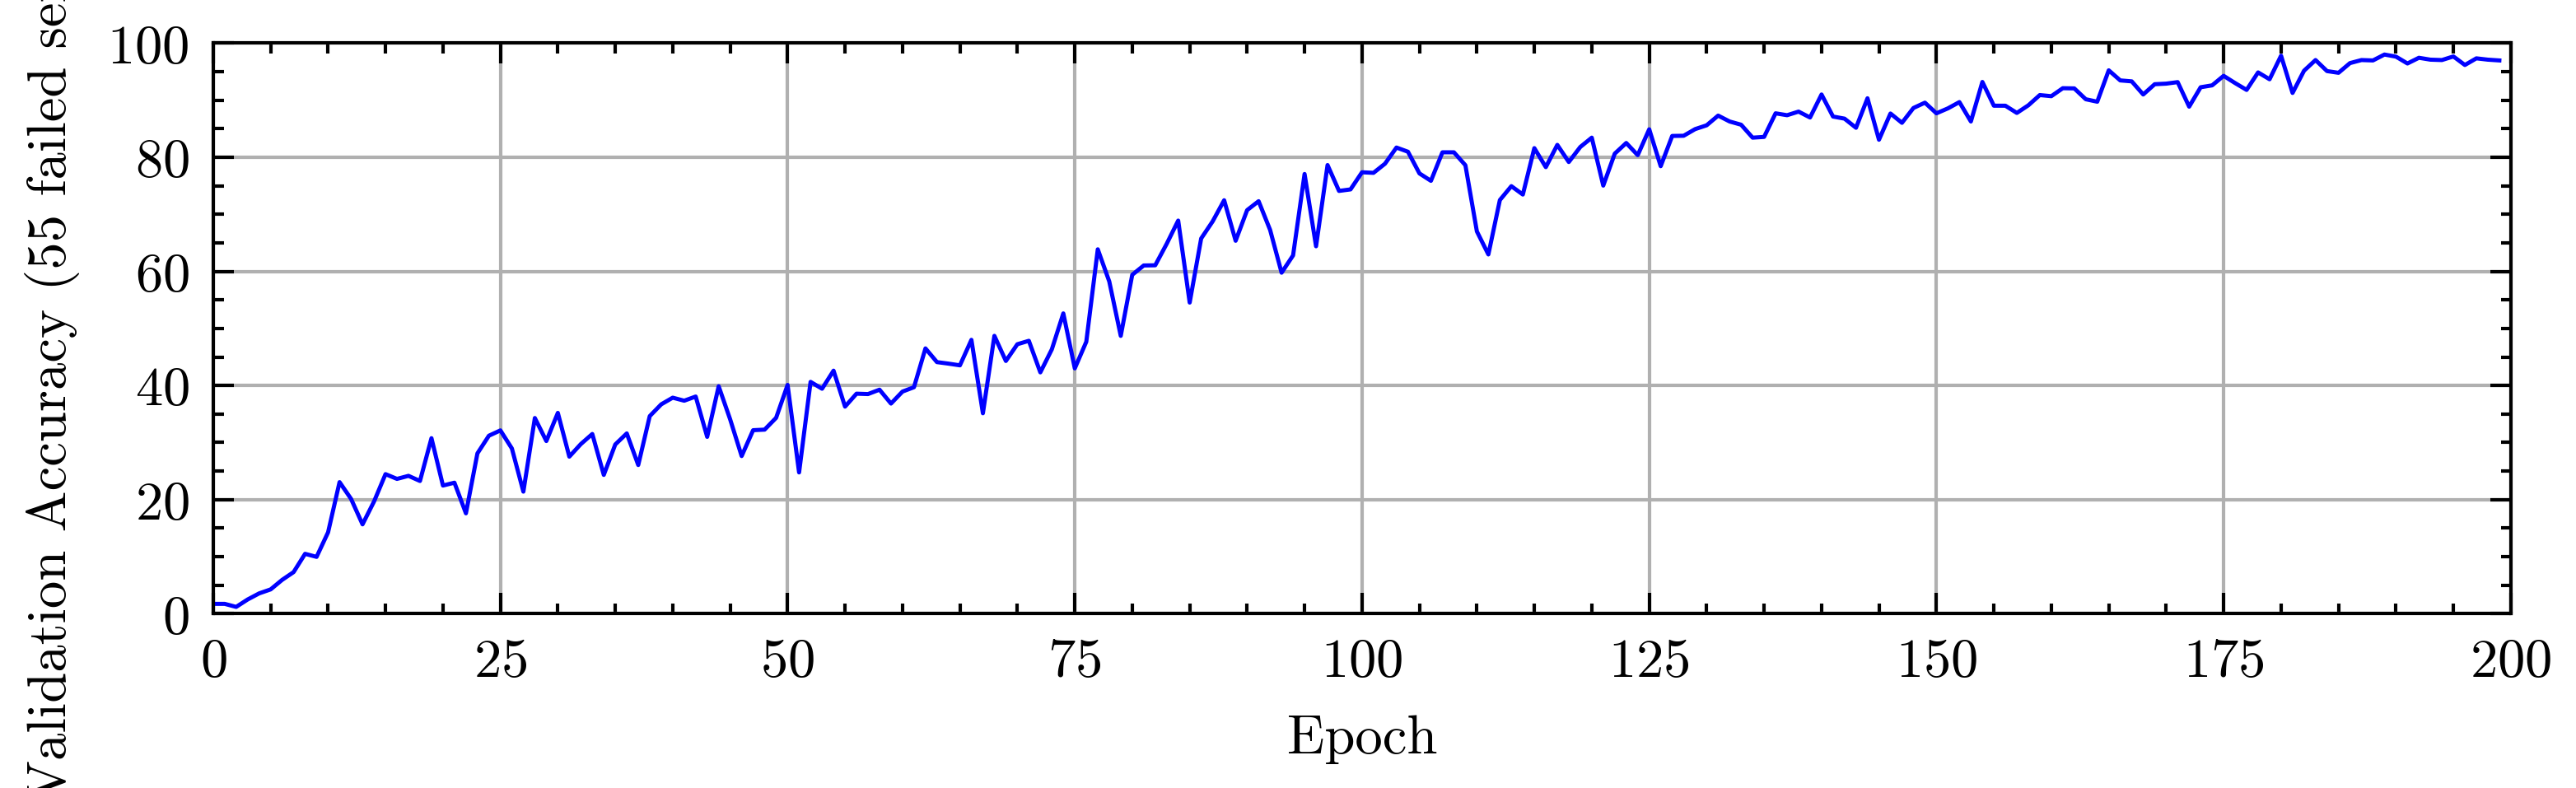

In [ ]:
plt.figure(figsize=(6, 1.5))
plt.plot(other_stats[0], color='blue', linewidth=0.6)
plt.ylim(0, 100)
plt.ylabel("Validation Accuracy (55 failed sensors)")
plt.xlim(0, 200)
plt.xlabel("Epoch")
plt.grid()

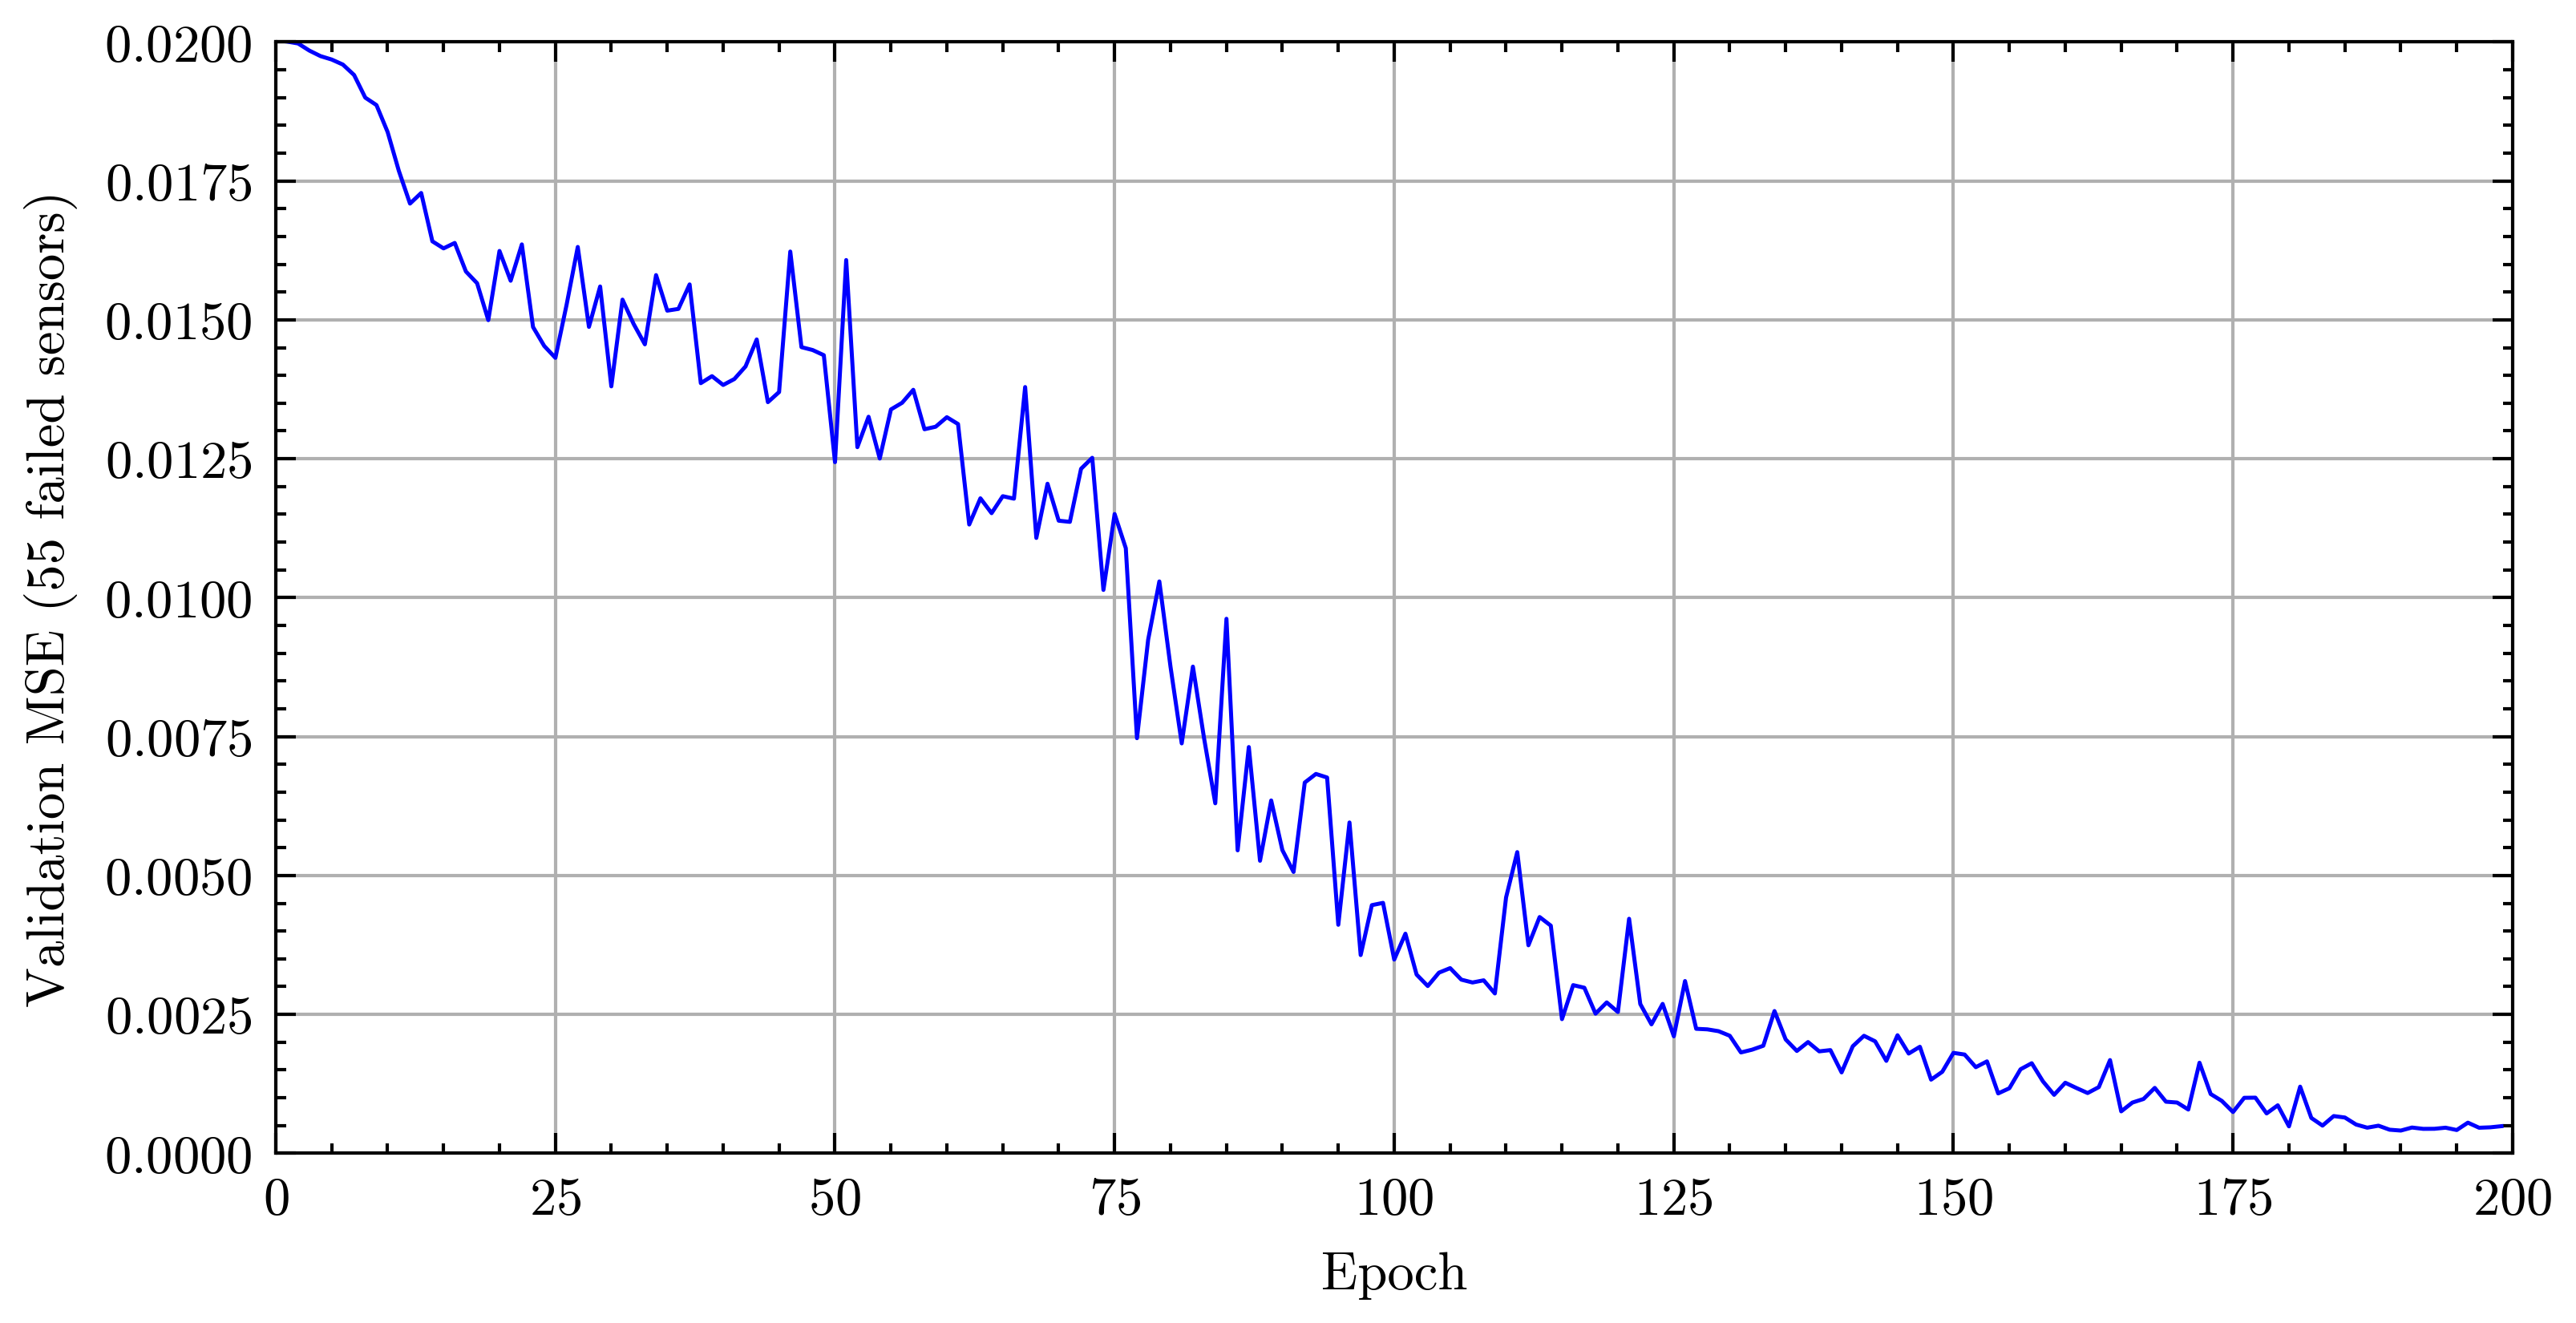

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(other_stats[1], color='blue', linewidth=0.6)
plt.ylim(0.000, 0.02)
# plt.yscale("log")
plt.ylabel("Validation MSE (55 failed sensors)")
plt.xlim(0, 200)
plt.xlabel("Epoch")
plt.grid()

In [ ]:
model

Sequential(
  (0): SDIDenseNet(
    (0): Conv2d(1, 24, kernel_size=(20, 1), stride=(5, 1), padding=(10, 0), bias=False)
    (1): DenseBlock(
      (layers): ModuleList(
        (0): Sequential(
          (0): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(24, 24, kernel_size=(5, 1), stride=(1, 1), padding=(2, 0))
          (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): ReLU()
          (5): Conv2d(24, 12, kernel_size=(1, 1), stride=(1, 1))
        )
        (1): Sequential(
          (0): BatchNorm2d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU()
          (2): Conv2d(36, 24, kernel_size=(5, 1), stride=(1, 1), padding=(2, 0))
          (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): ReLU()
          (5): Conv2d(24, 12, kernel_size=(1, 1), stride=(1, 1))
        )
 

In [ ]:
# state = torch.load("states/single-damage-b3d77283-b219-4eb5-9c5c-f44d76399ad7.pt")
# state = torch.load("states/single-damage-unc2-00a4c33e-984e-4dda-b0b7-d832392cf55c.pt")
# state = torch.load("states/single-damage-noise20-d9780746-040c-4899-865a-47377053f5b8.pt")
# state = torch.load("states/single-damage-unc2-noise20-4041a415-cb4d-49e9-831e-7245902b7f41.pt")
state = torch.load("states/single-damage-sparse-fc67aca3-4955-40b6-9875-18c8733af800.pt")
# state = torch.load("states/single-damage-noise20-sparse-1b540f97-d272-4c16-bcdf-041788f80093.pt")
# state = torch.load("states/single-damage-unc2-sparse-95cb6e1a-7a2d-444a-b899-833a922cfcd0.pt")
# state = torch.load("states/single-damage-unc2-noise20-sparse-deba7b9f-3079-473c-ae8a-de3a4ef333cf.pt")
model.load_state_dict(state)

<All keys matched successfully>

In [ ]:
do_real_test(model)

{'rw_mse': 0.009822241208541138,
 'rw_nll': 0.5987744927406311,
 'rw_err_s': 2.8933065550518222e-05,
 'rw_err_h': 0.0001403177302563563}

In [ ]:
(dmg_pred - 0.125) ** 2

0.023545287373139878

In [ ]:
with torch.inference_mode():
    model.eval()
    dmg_pred, loc_pred = model(test_data[None, None, ...].cuda())
dmg_pred = dmg_pred.squeeze().add(1).mul_(0.15).item()
loc_nll = -(loc_pred.squeeze().log_softmax(-1)[11].item())
max_nll = -(loc_pred.squeeze().log_softmax(-1).max().item())
smooth = dmg_pred * loc_pred.squeeze().softmax(-1)
hard = torch.zeros_like(test_target.squeeze())
hard[loc_pred.argmax()] = dmg_pred

In [ ]:
with torch.inference_mode():
    model.eval()
    # all_combos = [torch.combinations(torch.arange(9), i) for i in trange(1, 10)]
    # total_losses = [torch.zeros(len(combos)) for combos in all_combos]
    # total_mse = [torch.zeros(len(combos)) for combos in all_combos]
    # total_acc = [torch.zeros(len(combos)) for combos in all_combos]

    all_combos = torch.stack([
        torch.randperm(65)
        for _ in trange(664)
    ], 0)
    total_losses = torch.zeros_like(all_combos, dtype=float).T
    total_mse = torch.zeros_like(all_combos, dtype=float).T
    total_acc = torch.zeros_like(all_combos, dtype=float).T

    for x, y in tqdm(val_dl):
        # x = x[..., 1:-1]  # remove the stationary sensors
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]

        # for n, combos in enumerate(all_combos):
        #     n += 1
        for n in range(1, 66):
            combos = all_combos[:, :n]
            y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
            y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
            i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
            i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
            i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
            dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
            loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
            l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
            l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
            l = l_dmg + l_loc

            total_losses[n-1] += l

            distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
            total_mse[n-1]  += F.mse_loss(dmg_preds.add(1).mul(0.15), y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)).add(1).mul(0.15), reduction="none").mean(1).sum(0).cpu()
            # total_mse[n-1] += F.mse_loss(distributed_pred, y[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()

            total_acc[n-1] += (loc_preds.argmax(1) == y_loc[:, None]).sum(0).cpu()

  0%|          | 0/664 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
torch.save([te / len(val_dl.dataset) for te in total_acc], "saved_results/single-clean-dense-5.pt")

In [ ]:
with torch.inference_mode():
    model.eval()
    all_combos = torch.arange(9)[None, :]
    # for x, y in tqdm(val_dl):
        # x = x[..., 1:-1]  # remove the stationary sensors
    x, y = next(iter(test_dl))
    y_dmg, y_loc = y.max(-1, keepdim=True)
    y_loc = y_loc[:, 0]
    combos = all_combos[:, :]
    y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
    y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
    i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
    i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
    i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
    dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
    loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
    l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
    l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
    l = l_dmg + l_loc

    distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)

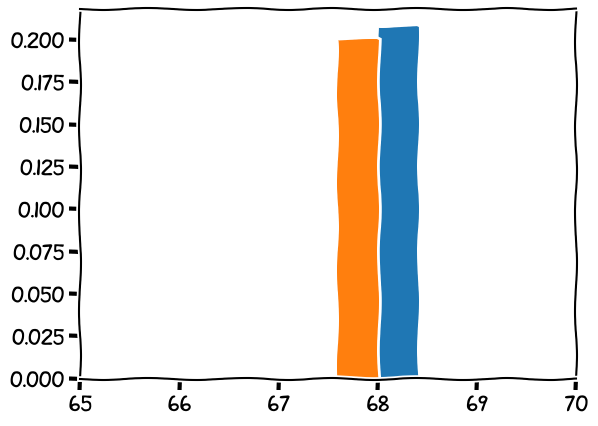

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt


IDX = 1
with plt.xkcd():
    fig = plt.figure()
    plt.bar(torch.arange(70) + 1.2, (distributed_pred[IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.4)
    plt.bar(torch.arange(70) + 0.8, (y[IDX].detach().cpu() + 1) * 0.15, width=0.4)
    plt.xlim(65, 70)
fig

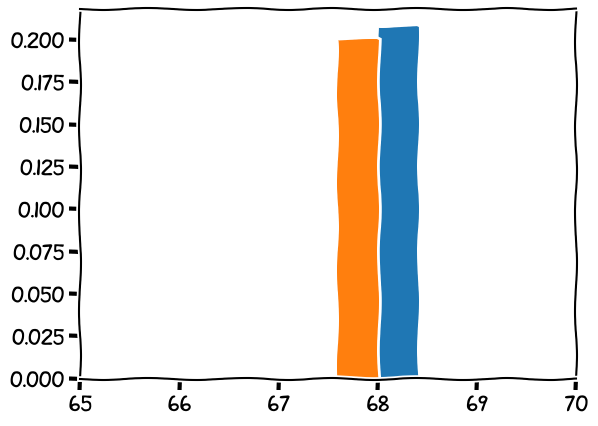

In [ ]:
all_combos = torch.randperm(9)[None, :]
dps = []
with torch.inference_mode():
    y_hat_dmg_, i_dmg_, y_hat_loc_, i_loc_ = model[2](model[:2](x.float()), False)
    y_hat_dmg_, i_dmg_, y_hat_loc_, i_loc_ = y_hat_dmg_.cpu(), i_dmg_.cpu(), y_hat_loc_.cpu(), i_loc_.cpu()
    for i in range(1, 10):
        combos = all_combos[:, :i]
        y_hat_dmg, y_hat_loc = y_hat_dmg_[..., combos], y_hat_loc_[..., combos]
        i_dmg, i_loc = i_dmg_[..., combos], i_loc_[..., combos]
        i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
        i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
        dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
        loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
        distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
        dps.append(distributed_pred.squeeze().detach().cpu())

IDX = 1
with plt.xkcd():
    fig = plt.figure()
    plt.bar(torch.arange(70) + 1.2, (distributed_pred[IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.4)
    plt.bar(torch.arange(70) + 0.8, (y[IDX].detach().cpu() + 1) * 0.15, width=0.4)
    plt.xlim(65, 70)
fig

In [ ]:
len(dps)

9

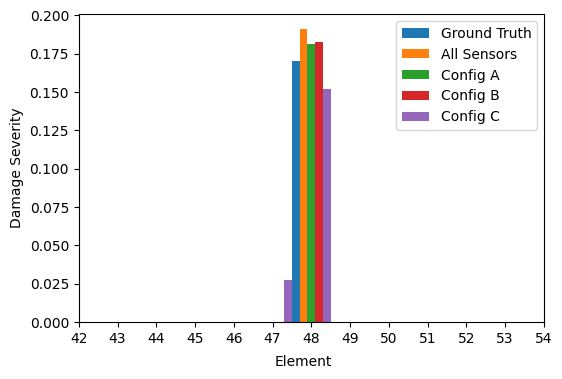

In [ ]:
IDX = 12
# with plt.xkcd():
fig = plt.figure(figsize=(6, 4))
plt.bar(torch.arange(70) + 0.6, (y[IDX].detach().cpu() + 1) * 0.15, width=0.2, label="Ground Truth")
plt.bar(torch.arange(70) + 0.8, (dps[-1][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="All Sensors")
plt.bar(torch.arange(70) + 1.0, (dps[5][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config A")
plt.bar(torch.arange(70) + 1.2, (dps[2][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config B")
plt.bar(torch.arange(70) + 1.4, (dps[0][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config C")
plt.xticks(torch.arange(13+42))
plt.xlim(42, 54)
# plt.ylim(0, 0.02)

plt.gca().legend(loc="upper right")
plt.gcf().text(0.5, 0.0, "Element", ha="center")
plt.gca().set_ylabel("Damage Severity")
fig.suptitle("")

fig

In [ ]:
dps[0][IDX].squeeze().detach().cpu().argsort()

tensor([41, 52, 51, 50, 49, 45, 44, 43, 42, 53, 40, 39, 38, 37, 36,  0, 34, 61,
        69, 68, 67, 66, 65, 64, 63, 62, 35, 60, 59, 58, 57, 56, 55, 54,  9, 17,
        16, 15, 14, 13, 12, 11, 10, 18,  8,  7,  6,  5,  4,  3,  2,  1, 24, 32,
        31, 30, 29, 28, 27, 26, 25, 33, 23, 22, 21, 20, 19, 46, 48, 47])

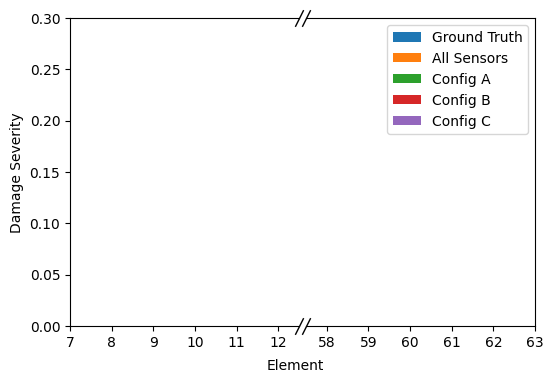

In [ ]:
# IDX=1
# IDX=2
IDX = 12
# with plt.xkcd():
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(6, 4))
for ax in axs:
    ax.bar(torch.arange(70) + 0.6, (y[IDX].detach().cpu() + 1) * 0.15, width=0.2, label="Ground Truth")
    ax.bar(torch.arange(70) + 0.8, (dps[-1][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="All Sensors")
    ax.bar(torch.arange(70) + 1.0, (dps[5][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config A")
    ax.bar(torch.arange(70) + 1.2, (dps[2][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config B")
    ax.bar(torch.arange(70) + 1.4, (dps[0][IDX].squeeze().detach().cpu() + 1) * 0.15, width=0.2, label="Config C")
    ax.set_xticks(torch.arange(70)+1)
    ax.set_ylim(0, 0.3)
    # plt.xlim(65, 70)
fig.subplots_adjust(wspace=0.03)
axs[0].set_xlim(7, 12.5)
axs[1].set_xlim(57.5, 63)

axs[0].spines.right.set_visible(False)
axs[1].spines.left.set_visible(False)
axs[1].tick_params(axis="y", left=False, right=False)

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
axs[0].plot([1, 1], [0, 1], transform=axs[0].transAxes, **kwargs)
axs[1].plot([0, 0], [0, 1], transform=axs[1].transAxes, **kwargs)

axs[1].legend(loc="upper right")
fig.text(0.5, 0.0, "Element", ha="center")
axs[0].set_ylabel("Damage Severity")
fig.suptitle("")
fig

In [ ]:
fig.subplots_adjust()

In [ ]:
9, 53, 11, 4, 7, 50, 17, 56, 47

In [ ]:
combos[0, :10]

tensor([3, 4, 0, 2, 6, 8, 5, 1, 7])

In [ ]:
ax.tich

In [ ]:
(total_acc / len(val_dl.dataset)).mean(-1)

tensor([0.5285, 0.6766, 0.7534, 0.7871, 0.8165, 0.8301, 0.8378, 0.8439, 0.8498,
        0.8524, 0.8550, 0.8578, 0.8599, 0.8612, 0.8626, 0.8640, 0.8649, 0.8659,
        0.8668, 0.8674, 0.8682, 0.8689, 0.8693, 0.8699, 0.8704, 0.8707, 0.8712,
        0.8717, 0.8720, 0.8723, 0.8725, 0.8728, 0.8730, 0.8733, 0.8735, 0.8738,
        0.8739, 0.8741, 0.8743, 0.8745, 0.8747, 0.8748, 0.8750, 0.8751, 0.8754,
        0.8755, 0.8756, 0.8757, 0.8758, 0.8759, 0.8759, 0.8761, 0.8761, 0.8762,
        0.8763, 0.8764, 0.8765, 0.8766, 0.8767, 0.8768, 0.8770, 0.8770, 0.8771,
        0.8772, 0.8773], dtype=torch.float64)

In [ ]:
loc = []
dmg = []
with torch.inference_mode():
    for i in range(1, 66):
        combos = all_combos[:, :i]
        y_hat_dmg, i_dmg, y_hat_loc, i_loc = model[2](model[:2](x.float()), False)
        y_hat_dmg, y_hat_loc = y_hat_dmg[..., combos], y_hat_loc[..., combos]
        i_dmg, i_loc = i_dmg[..., combos], i_loc[..., combos]
        i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
        i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
        dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
        loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
        loc.append(loc_preds.argmax(1).cpu())
        dmg.append(dmg_preds.squeeze(1).sigmoid().mul(0.3).cpu())

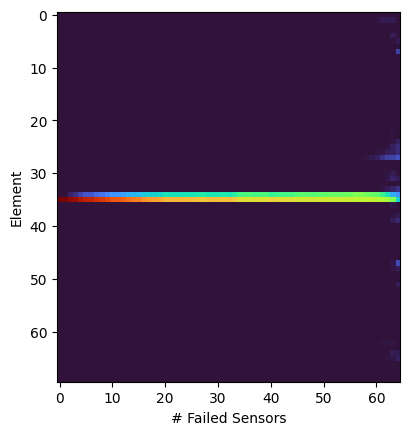

In [ ]:
# plt.plot(loc[:, 0, 1]
res = (loc[:, 12, :, None] == torch.arange(70)[None, None, :]).float().mean(1)
plt.ylabel("Element")
plt.xlabel("# Failed Sensors")
plt.imshow(res.T.numpy()[:, ::-1], cmap="turbo")
# plt.imshow(1-res.T.numpy()[:, ::-1], cmap="gray")

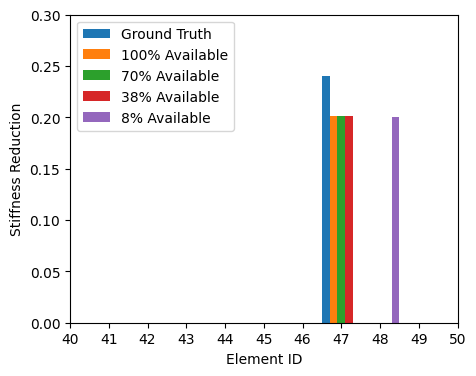

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt


# plt.plot(np.arange(65), y_loc[10].cpu().repeat(65), '--', color='r', label="Ground Truth")
# plt.plot(loc[:, 10, 4], '.-', label="Predicted Element")
# plt.legend();

I = 16
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(np.arange(70)-0.4, y[I].add(1).mul(0.15).cpu().numpy(), width=0.2, label="Ground Truth")
ax.bar(loc[64, I, 0]-0.2, dmg[64, 0, 0], width=0.2, label="100% Available")
ax.bar(loc[44, I, 0], dmg[44, 0, 0], width=0.2, label="70% Available")
ax.bar(loc[24, I, 0]+0.2, dmg[24, 0, 0], width=0.2, label="38% Available")
ax.bar(loc[4, I, 0]+0.4, dmg[4, 0, 0], width=0.2, label="8% Available")
ax.set_xticks(np.arange(0, 71))
ax.set_xlim(y[I].argmax().item()//10*10, min(y[I].argmax().item()//10*10+10, 70))
ax.set_xlabel("Element ID")
ax.set_ylim(0, 0.3)
ax.set_ylabel("Stiffness Reduction")
ax.legend();

In [ ]:
import matplotlib.pyplot as plt
c = [
    "#fc618d",
    "#7bd88f",
    "#fd9353"
]

N_SENSORS = 65
plt.style.use("default")
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(torch.arange(N_SENSORS).flip(0), [torch.median(ta) for ta in total_acc], color=c[2], label="Median")
plt.fill_between(
    torch.arange(N_SENSORS).flip(0),
    [torch.quantile(ta, 0.0) for ta in total_acc],
    [torch.quantile(ta, 1.0) for ta in total_acc],
    color=c[2],
    alpha=0.33,
    label="Min/Max"
)
plt.fill_between(
    torch.arange(N_SENSORS).flip(0),
    [torch.quantile(ta, 0.1) for ta in total_acc],
    [torch.quantile(ta, 0.9) for ta in total_acc],
    color=c[2],
    alpha=0.67,
    label="10%/90% Percentile"
)
plt.ylim(0.0, 1.0)
plt.ylabel("Accuracy (%)")
plt.xlabel("# Failed Sensors")
plt.gca().set_title("")
plt.legend()

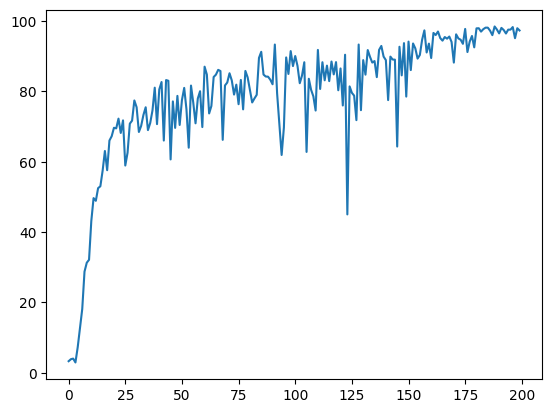

In [ ]:
import matplotlib.pyplot as plt
plt.plot(other_stats[0])

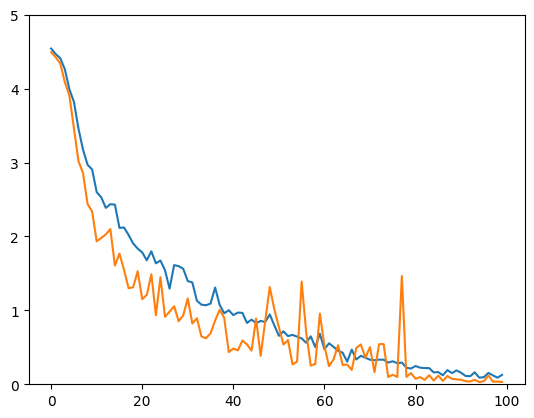

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.ylim(0, 5)
# plt.yscale("log")
plt.show()

In [ ]:
with torch.inference_mode():
    model.eval()
    dmg_pred, loc_pred = model(test_data[None, None, ...].cuda())
dmg_pred = dmg_pred.squeeze().add(1).mul_(0.15).item()
loc_nll = -(loc_pred.squeeze().log_softmax(-1)[11].item())
max_nll = -(loc_pred.squeeze().log_softmax(-1).max().item())
smooth = dmg_pred * loc_pred.squeeze().softmax(-1)
hard = torch.zeros_like(test_target.squeeze())
hard[loc_pred.argmax()] = dmg_pred

(0.0, 0.3)

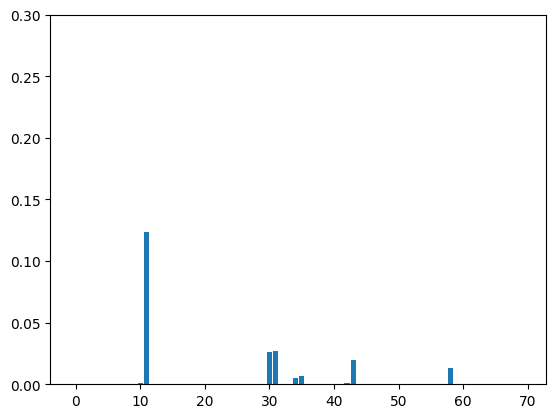

In [ ]:
plt.bar(torch.arange(70), (loc_pred.softmax(-1) * dmg_pred).detach().cpu().squeeze())
plt.ylim(0, 0.3)

In [ ]:
from uuid import uuid4
torch.save(model.state_dict(), f"states/single-damage-sparse-{uuid4()}.pt")

In [ ]:
torch.combinations(torch.arange(9), r=4).shape

torch.Size([126, 4])

In [ ]:
model.eval()

all_combos = [torch.combinations(torch.arange(9), r=9-i) for i in range(9)]

total_losses = [torch.zeros((all_combos[i].shape[0],)) for i in range(9)]
total_mse = [torch.zeros((all_combos[i].shape[0],)) for i in range(9)]
with torch.inference_mode():
    for x, y in tqdm(val_dl):
        y_dmg, y_loc = y.max(-1, keepdim=True)
        y_loc = y_loc[:, 0]

        y_hat_dmg_, i_dmg_, y_hat_loc_, i_loc_ = model[2](model[:2](x.float()), False)
        for num_missing in range(0, 9, 1):
            combos = all_combos[num_missing]
            y_hat_dmg, y_hat_loc = y_hat_dmg_[..., combos], y_hat_loc_[..., combos]
            i_dmg, i_loc = i_dmg_[..., combos], i_loc_[..., combos]
            i_dmg = i_dmg / (i_dmg.sum(-1, keepdim=True) + 1e-12)
            i_loc = i_loc / (i_loc.sum(-1, keepdim=True) + 1e-12)
            dmg_preds = torch.einsum("becs,becs->bec", y_hat_dmg, i_dmg)
            loc_preds = torch.einsum("becs,becs->bec", y_hat_loc, i_loc)
            l_dmg = F.mse_loss(dmg_preds, y_dmg[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()
            l_loc = F.cross_entropy(loc_preds, y_loc[..., None].expand(-1, loc_preds.size(-1)), reduction="none").sum(0).cpu()
            l = l_dmg + l_loc
            total_losses[num_missing] += l

            distributed_pred = (dmg_preds.add(1).div(2) * loc_preds.softmax(1)).mul(2).sub(1)
            total_mse[num_missing] += F.mse_loss(distributed_pred, y[..., None].expand(-1, -1, dmg_preds.size(-1)), reduction="none").mean(1).sum(0).cpu()

  0%|          | 0/94 [00:00<?, ?it/s]

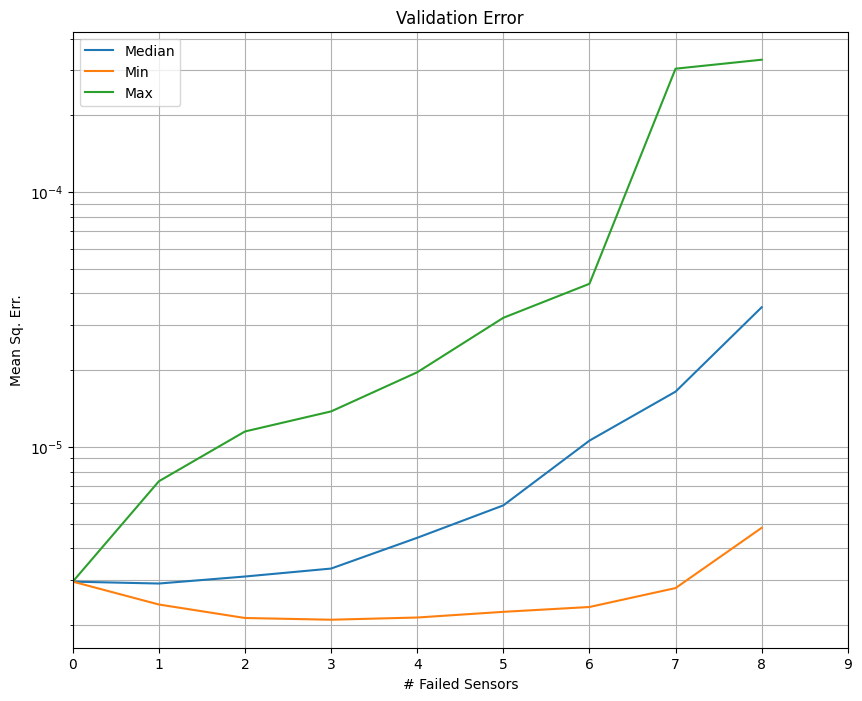

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 8))
ax.set_ylabel("Mean Sq. Err.")
ax.set_xlabel("# Failed Sensors")
ax.set_title("Validation Error")

ax.plot(torch.arange(0, 9, 1), [torch.median(mse) * 0.0225 / len(val_dl.dataset) for mse in total_mse], label="Median")
ax.plot(torch.arange(0, 9, 1), [torch.min(mse) * 0.0225 / len(val_dl.dataset) for mse in total_mse], label="Min")
ax.plot(torch.arange(0, 9, 1), [torch.max(mse) * 0.0225 / len(val_dl.dataset) for mse in total_mse], label="Max")

ax.legend()
ax.set_yscale("log")
ax.set_xlim(0, 9)
ax.grid(which="both")